# 🧠 Mental Health Intelligence Platform

## Phase 4 — Exploratory Data Analysis

### Overview

The unified OSMI dataset combines multiple survey years, enabling longitudinal analysis of workplace mental health trends.

Rather than examining a single point in time, this notebook investigates how workplace policies, employee attitudes, and treatment-seeking behaviour have evolved over several years.

---

### Objectives

This notebook aims to:

- Explore survey participation over time
- Analyze treatment-seeking trends
- Evaluate changes in workplace support
- Examine employer benefits across survey years
- Investigate changes in mental health awareness
- Identify long-term patterns in employee experiences

## Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

pd.set_option("display.max_columns", None)

## Load Dataset

In [2]:
df = pd.read_csv("../../data/processed/harmonized_osmi_data.csv")

print(df.shape)

df.head()

(3082, 70)


,source_file,survey_year,self_employed,no_employees,tech_company,primary_role_tech,benefits,know_options,formal_discussion,resources,anonymity,leave_ease,comfort_physical_mental,comfort_supervisor,discussed_with_employer,comfort_coworkers,discussed_with_coworkers,coworker_discussed_with_you,employer_importance_physical,employer_importance_mental,coverage_mental_health,know_resources,reveal_to_clients,reveal_to_coworkers,productivity_affected,productivity_percent_affected,have_prev_employers,prev_tech_company,prev_benefits,prev_know_options,prev_formal_discussion,prev_resources,prev_anonymity,prev_comfort_physical_mental,prev_comfort_supervisor,prev_discussed_with_employer,prev_comfort_coworkers,prev_discussed_with_coworkers,prev_employer_importance_physical,prev_employer_importance_mental,currently_disordered,diagnosed_disorder,past_disorder,sought_treatment,family_history,interference_when_treated,interference_when_not_treated,observations_less_likely_reveal,share_with_friends_family,bring_up_physical_interview,bring_up_mental_interview,bring_up_mental_why,openly_identified,identified_affected_career,identified_affected_how,team_reaction_if_knew,observed_unsupportive_response,unsupportive_response_desc,observed_supportive_response,industry_support_rating,improvement_suggestions,additional_comments,willing_to_interview,age,gender,country_live,state_live,race,country_work,state_work
0,2014,2014,NaN,2025-06-01 00:00:00,Yes,NaN,Yes,Don't Know,No,Yes,Yes,Somewhat easy,Yes,Yes,No,Some of them,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,No,Often,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Male,NaN,NaN,NaN,NaN,NaN
1,2014,2014,NaN,More than 1000,No,NaN,Don't Know,No,Don't Know,Don't Know,Don't Know,Don't Know,Don't know,No,Maybe,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,No,Rarely,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Other,NaN,NaN,NaN,NaN,NaN
2,2014,2014,NaN,2025-06-01 00:00:00,Yes,NaN,No,No,No,No,Don't Know,Somewhat difficult,No,Yes,No,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,No,Rarely,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Other,NaN,NaN,NaN,NaN,NaN
3,2014,2014,NaN,26-100,Yes,NaN,No,Yes,No,No,No,Somewhat difficult,No,No,Yes,Some of them,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,Yes,Often,NaN,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Other,NaN,NaN,NaN,NaN,NaN
4,2014,2014,NaN,100-500,Yes,NaN,Yes,No,Don't Know,Don't Know,Don't Know,Don't Know,Don't know,Yes,No,Some of them,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,No,Never,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Male,NaN,NaN,NaN,NaN,NaN


## Survey Participation

Understanding the number of responses collected each year provides context for all subsequent trend analyses.

Differences in participation levels should be considered when interpreting changes over time.

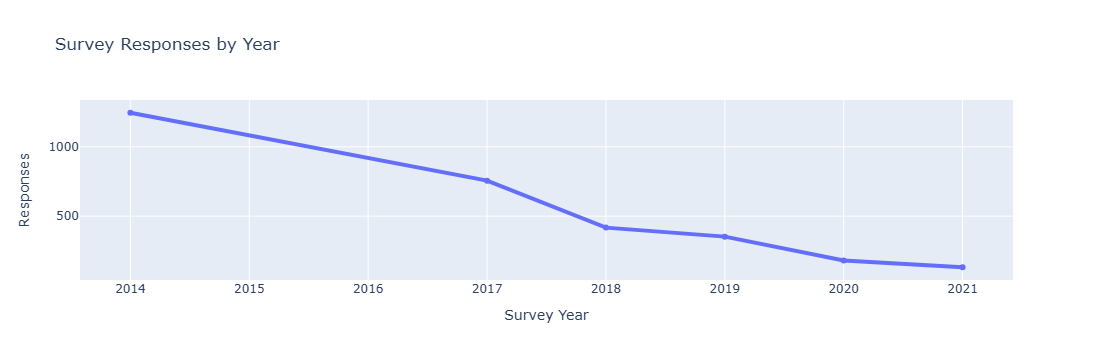

In [3]:
responses = (
    df["survey_year"]
    .value_counts()
    .sort_index()
    .reset_index()
)

responses.columns = [
    "Survey Year",
    "Responses"
]

fig = px.line(
    responses,
    x="Survey Year",
    y="Responses",
    markers=True,
    title="Survey Responses by Year"
)

fig.update_traces(line_width=4)

fig.show()

## Treatment Seeking Over Time

This section evaluates whether the proportion of respondents seeking professional mental health treatment has changed across survey years.

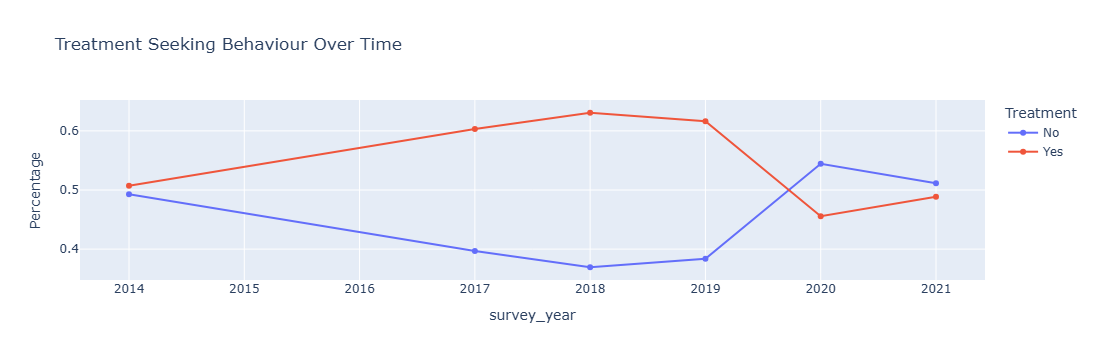

In [4]:
trend = pd.crosstab(
    df["survey_year"],
    df["sought_treatment"],
    normalize="index"
)

trend = (
    trend
    .reset_index()
    .melt(
        id_vars="survey_year",
        var_name="Treatment",
        value_name="Percentage"
    )
)

fig = px.line(
    trend,
    x="survey_year",
    y="Percentage",
    color="Treatment",
    markers=True,
    title="Treatment Seeking Behaviour Over Time"
)

fig.show()

## Family History Trends

This section examines whether the proportion of respondents reporting a family history of mental illness changes over time.

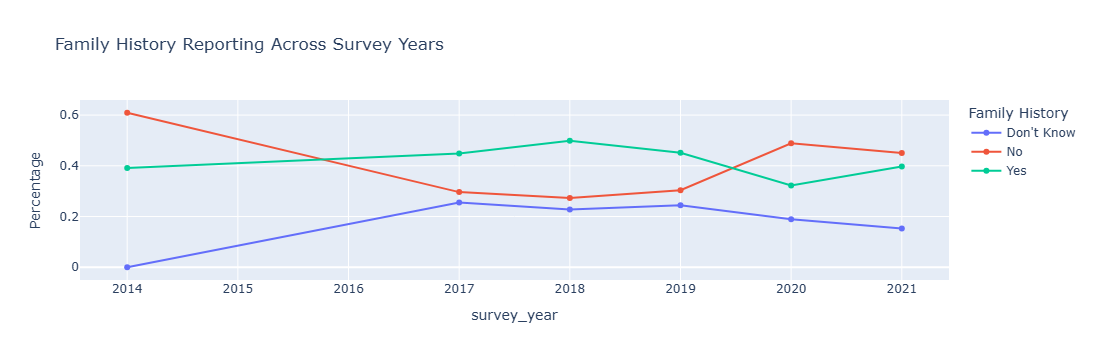

In [5]:
family = pd.crosstab(
    df["survey_year"],
    df["family_history"],
    normalize="index"
)

family = (
    family
    .reset_index()
    .melt(
        id_vars="survey_year",
        var_name="Family History",
        value_name="Percentage"
    )
)

fig = px.line(
    family,
    x="survey_year",
    y="Percentage",
    color="Family History",
    markers=True,
    title="Family History Reporting Across Survey Years"
)

fig.show()

## Employer Mental Health Benefits

This analysis investigates how the availability of employer-sponsored mental health benefits has evolved over time.

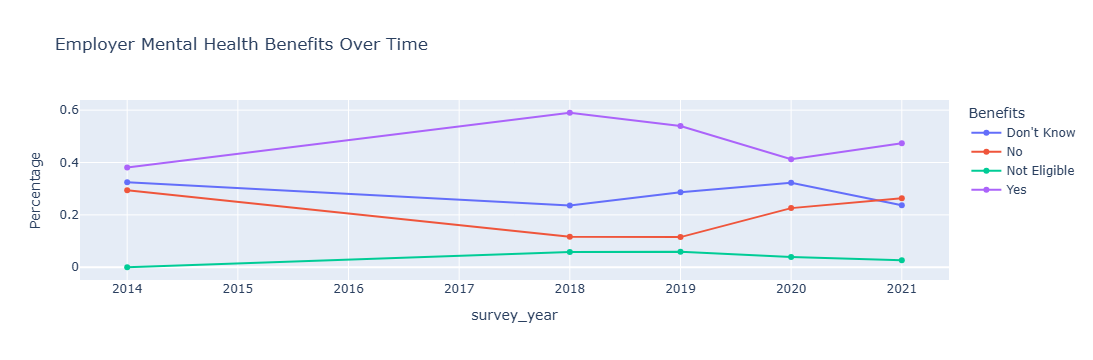

In [6]:
benefits = pd.crosstab(
    df["survey_year"],
    df["benefits"],
    normalize="index"
)

benefits = (
    benefits
    .reset_index()
    .melt(
        id_vars="survey_year",
        var_name="Benefits",
        value_name="Percentage"
    )
)

fig = px.line(
    benefits,
    x="survey_year",
    y="Percentage",
    color="Benefits",
    markers=True,
    title="Employer Mental Health Benefits Over Time"
)

fig.show()

## Workplace Mental Health Resources

Organizations may provide employees with counseling services, employee assistance programs, or other mental health resources.

This section examines changes in resource availability across survey years.

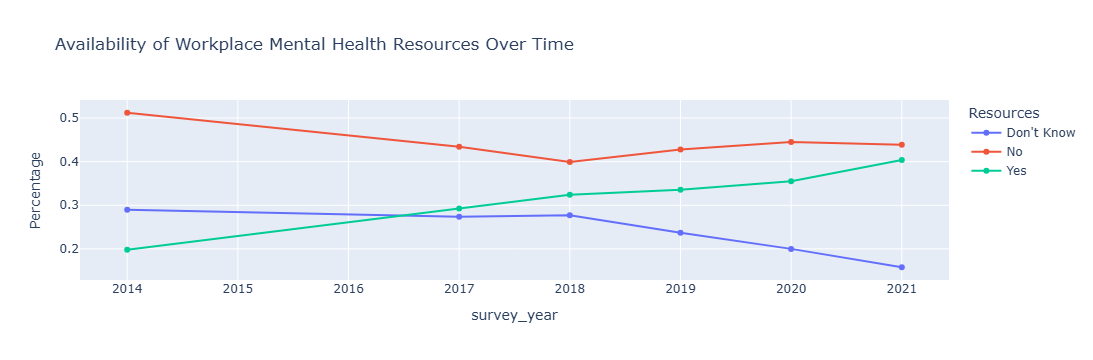

In [7]:
resources = pd.crosstab(
    df["survey_year"],
    df["resources"],
    normalize="index"
)

resources = (
    resources
    .reset_index()
    .melt(
        id_vars="survey_year",
        var_name="Resources",
        value_name="Percentage"
    )
)

fig = px.line(
    resources,
    x="survey_year",
    y="Percentage",
    color="Resources",
    markers=True,
    title="Availability of Workplace Mental Health Resources Over Time"
)

fig.show()

## Workplace Discussions About Mental Health

Open discussions regarding mental health can help reduce stigma and improve awareness.

This section evaluates changes in formal workplace discussions over time.

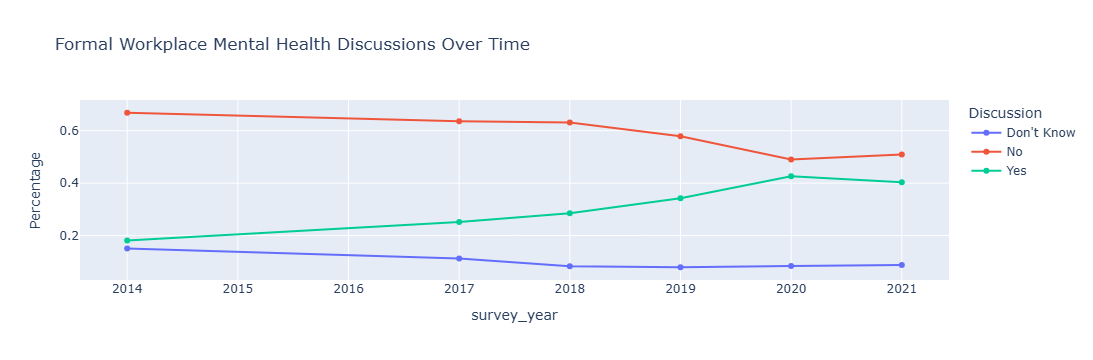

In [8]:
discussion = pd.crosstab(
    df["survey_year"],
    df["formal_discussion"],
    normalize="index"
)

discussion = (
    discussion
    .reset_index()
    .melt(
        id_vars="survey_year",
        var_name="Discussion",
        value_name="Percentage"
    )
)

fig = px.line(
    discussion,
    x="survey_year",
    y="Percentage",
    color="Discussion",
    markers=True,
    title="Formal Workplace Mental Health Discussions Over Time"
)

fig.show()

## Ease of Taking Mental Health Leave

This section explores whether respondents perceive improvements in workplace support for taking mental health leave across survey years.

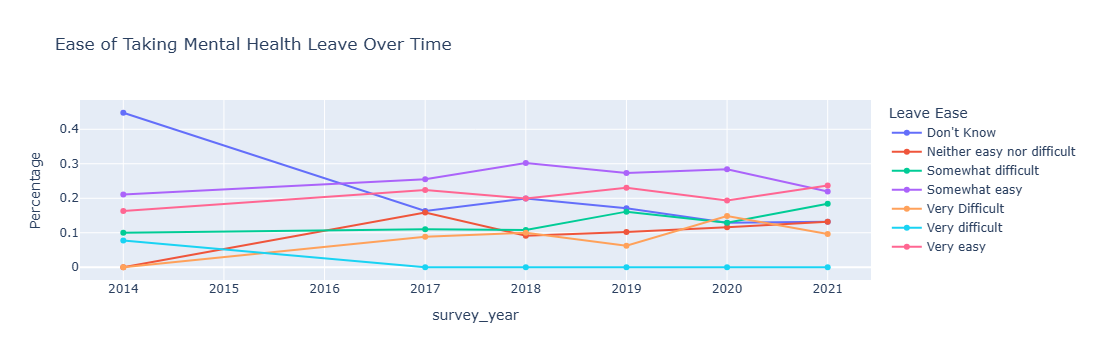

In [9]:
leave = pd.crosstab(
    df["survey_year"],
    df["leave_ease"],
    normalize="index"
)

leave = (
    leave
    .reset_index()
    .melt(
        id_vars="survey_year",
        var_name="Leave Ease",
        value_name="Percentage"
    )
)

fig = px.line(
    leave,
    x="survey_year",
    y="Percentage",
    color="Leave Ease",
    markers=True,
    title="Ease of Taking Mental Health Leave Over Time"
)

fig.show()